In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.interpolate import UnivariateSpline
from collections import Counter

import gc
import itertools
import os
import glob

# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

In [2]:
final_results = pd.read_pickle("/home/mattia/Downloads/ALICE/ALL_MC_with_mother_hyp.pkl")

print(f"The uploaded dataframe has {len(final_results):_} rows and {len(final_results.columns):_} columns.")
memory = final_results.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:_.2f} MB in RAM memory")

display( pd.concat([final_results.head(5),final_results.tail(5)]) )

The uploaded dataframe has 52_608_601 rows and 20 columns.
It occupies 10_884.94 MB in RAM memory


,dcaXY_product,inv_mass,anti_mass,pt,decay_length,cos_pointing,neg_pt,neg_TPCka,neg_TOFka,neg_fDcaXY,pos_pt,pos_TPCpi,pos_TOFpi,pos_fDcaXY,neg_TPCpi,neg_TOFpi,pos_TPCka,pos_TOFka,truth,mother_hyp
0,-0.000008,1.803016,1.778223,1.575074,0.004660,0.995067,1.014060,-0.055695,-999.0,0.002824,0.978806,1.080044,1.812436,-0.002688,0.413968,-999.0,1.759560,-3.427866,0,BothSignal
1,0.000008,2.215073,2.207963,0.473187,0.013202,0.053475,1.014060,-0.055695,-999.0,0.002824,1.124787,0.829078,-999.000000,0.002763,0.413968,-999.0,1.572557,-999.000000,0,BothSignal
4,-0.000006,1.802861,1.811290,1.872615,0.004316,-0.990615,1.388882,2.086939,-999.0,0.002292,0.978806,1.080044,1.812436,-0.002688,1.018354,-999.0,1.759560,-3.427866,0,Anti-D0
5,0.000006,0.753274,0.809453,2.512969,0.010321,-0.959486,1.388882,2.086939,-999.0,0.002292,1.124787,0.829078,-999.000000,0.002763,1.018354,-999.0,1.572557,-999.000000,0,Anti-D0
6,0.000005,1.906000,1.813098,0.518201,0.029233,-0.969578,0.483096,-5.426188,-999.0,-0.002027,0.978806,1.080044,1.812436,-0.002688,-0.134088,-999.0,1.759560,-3.427866,0,Anti-D0
71693460,-0.000007,0.817484,0.819815,1.942073,0.027600,-0.992015,0.931452,0.829556,-999.0,-0.006850,1.039324,-0.338925,-5.902093,0.001065,0.190194,-999.0,0.125043,-18.729809,0,D0
71693461,-0.000029,1.276946,1.442003,0.654153,0.484136,0.599167,0.964872,0.921494,-999.0,0.000284,0.321738,-0.598109,-999.000000,-0.103506,0.410306,-999.0,-10.056605,-999.000000,0,D0
71693462,0.000004,2.277966,2.295973,0.220301,0.159155,-0.915865,0.964872,0.921494,-999.0,0.000284,0.770427,0.555073,-999.000000,0.014991,0.410306,-999.0,-0.200770,-999.000000,0,BothSignal
71693463,-0.001381,0.990568,0.992497,0.324600,0.118799,-0.578420,0.317333,-8.562991,-999.0,0.013340,0.321738,-0.598109,-999.000000,-0.103506,1.895879,-999.0,-10.056605,-999.000000,0,BothSignal
71693464,0.000200,1.194881,1.045351,0.706488,0.026848,-0.106647,0.317333,-8.562991,-999.0,0.013340,0.770427,0.555073,-999.000000,0.014991,1.895879,-999.0,-0.200770,-999.000000,0,Anti-D0


In [3]:
d0_tot = np.sum( final_results["truth"] == 1 )
anti_d0_tot = np.sum( final_results["truth"] == -1 )
signal_tot = d0_tot + anti_d0_tot
num_bg_pairs = np.sum( final_results["truth"] == 0  )
print("Number of D0:      ", d0_tot )
print("Number of anti-D0: ", anti_d0_tot )
print(f"Number of background pairs: {num_bg_pairs:_}")
print(f"Fraction of D0 and anti-D0 over total: {(d0_tot+anti_d0_tot)/len(final_results) * 100:.4f}%"  )

Number of D0:       11849
Number of anti-D0:  12396
Number of background pairs: 52_584_356
Fraction of D0 and anti-D0 over total: 0.0461%


# Edit the masks to replicate the cuts done in the real data

In [4]:
# Pair variable cuts: cut on these at the start in order to reduce the following boolean evaluations by reducing the size of the dataframe.
COS_CUT = 0.98
PT_MIN, PT_MAX = 2, 8

pt_mask = final_results["pt"].between(PT_MIN, PT_MAX )
cos_mask = (final_results["cos_pointing"] > COS_CUT)
dca_mask = final_results["dcaXY_product"] < -5e-05

mask =  pt_mask & cos_mask & dca_mask
final_results = final_results[mask]

new_Ka_hyp_neg =  (  final_results["neg_TPCka"].abs() < 2 ) & \
        ( ( (final_results["neg_pt"].between(0, 1.4)) & (final_results["neg_TOFka"].abs() < 4) ) |
          ( (final_results["neg_pt"].between(1.4, 3.0)) & (final_results["neg_TOFka"].abs() < 3) ) |
          ( (final_results["neg_pt"].between(0, 3.0)) & (final_results["neg_TOFka"]==-999) )
        )

new_Ka_hyp_pos =  (  final_results["pos_TPCka"].abs() < 2 ) & \
            ( ( (final_results["pos_pt"].between(0, 1.4)) & (final_results["pos_TOFka"].abs() < 4) ) |
              ( (final_results["pos_pt"].between(1.4, 3.0)) & (final_results["pos_TOFka"].abs() < 3) ) |
              ( (final_results["pos_pt"].between(0, 3.0)) & (final_results["pos_TOFka"]==-999) )
            )

new_Pi_hyp_neg =  (  final_results["neg_TPCpi"].abs() < 2 ) & \
            ( ( (final_results["neg_pt"].between(0, 1.4)) & (final_results["neg_TOFpi"].abs() < 4) ) |
              ( (final_results["neg_pt"].between(1.4, 3.0)) & (final_results["neg_TOFpi"].abs() < 3) ) |
              ( (final_results["neg_pt"].between(0, 3.0)) & (final_results["neg_TOFpi"]==-999) )
            )

new_Pi_hyp_pos =  (  final_results["pos_TPCpi"].abs() < 2 ) & \
            ( ( (final_results["pos_pt"].between(0, 1.4)) & (final_results["pos_TOFpi"].abs() < 4) ) |
              ( (final_results["pos_pt"].between(1.4, 3.0)) & (final_results["pos_TOFpi"].abs() < 3) ) |
              ( (final_results["pos_pt"].between(0, 3.0)) & (final_results["pos_TOFpi"]==-999) )
            )

new_undecided_neg = new_Ka_hyp_neg & new_Pi_hyp_neg
new_undecided_pos = new_Ka_hyp_pos & new_Pi_hyp_pos
new_undecided_hyp = new_undecided_neg & new_undecided_pos

new_Ka_hyp = new_Ka_hyp_neg | new_Ka_hyp_pos
new_Pi_hyp = new_Pi_hyp_pos | new_Pi_hyp_neg

new_D0_sure_hyp = new_Ka_hyp_neg & new_Pi_hyp_pos
new_D0_uncert_hyp = ( (new_undecided_neg & new_Pi_hyp_pos) | (new_undecided_pos & new_Ka_hyp_neg) )
new_D0 = new_D0_sure_hyp | new_D0_uncert_hyp

new_antiD0_sure_hyp = new_Ka_hyp_pos & new_Pi_hyp_neg
new_antiD0_uncert_hyp = ( (new_undecided_neg & new_Ka_hyp_pos) | (new_undecided_pos & new_Pi_hyp_neg) )
new_antiD0 = new_antiD0_sure_hyp | new_antiD0_uncert_hyp

final_results["new_particle"] = np.select( condlist=[new_undecided_hyp, new_D0, new_antiD0 ],
                                choicelist=["Undecided", "D0", "Anti-D0"], default="Bkg" )
signal_mask = final_results["new_particle"] != "Bkg"

final_results = final_results[signal_mask]
mask_true_d0 = ( final_results["truth"] == 1 )
mask_true_anti_d0 = ( final_results["truth"] == -1 )
mask_signal = ( (mask_true_d0) | (mask_true_anti_d0) )
mask_background = ( final_results["truth"] == 0 )

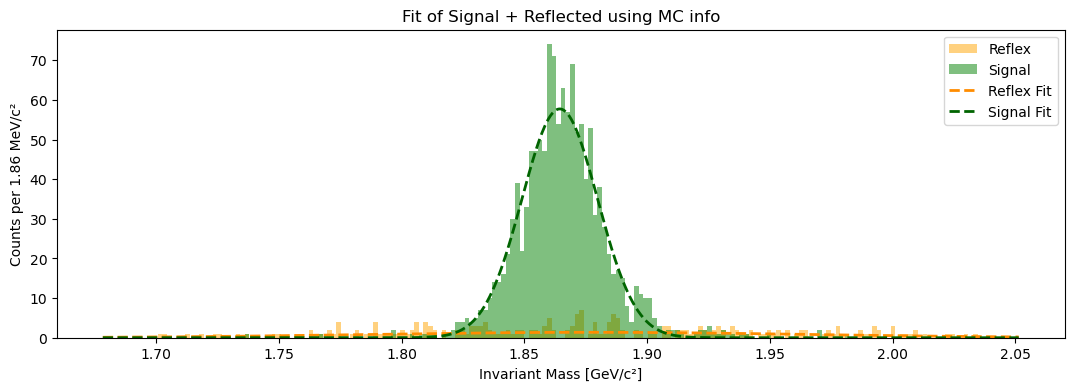

N1 value (reflex): 0.305
N1 value (signal): 2.227
Ratio N1/N2 (reflex/sign): 0.137


In [5]:
# --- Fit function: Gaussian---
def fit_gauss_mc(x, k, mu1, sigma1):
    return k * norm.pdf(x, loc=mu1, scale=sigma1) 

# Initializations.
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 200
binsize = (MAX_MASS - MIN_MASS)/N_BINS

# --- Initial parameter guesses ---
k_param = 100
gauss_params = [m_d0, 0.05]

# Histogram of signal and reflected part data only
# reflected part:
# 1) Truth==-1, misclassified as D0-> anti_mass
wrong_anti_D0 = (final_results["truth"] == -1) & (final_results["new_particle"] == "D0")
# 2) Truth==1, misclassified as anti-D0-> inv_mass
wrong_D0 = (final_results["truth"] == 1) & (final_results["new_particle"] == "Anti-D0")
# 3) Undecided, with the opposite mass correspoding to the truth value
Undecided_D0 = (final_results["truth"] == 1) & (final_results["new_particle"] == "Undecided")
Undecided_Anti_D0 = (final_results["truth"] == -1) & (final_results["new_particle"] == "Undecided")

reflex_data = np.select(condlist = [ wrong_anti_D0 | Undecided_Anti_D0, wrong_D0 | Undecided_D0 ],
                        choicelist = [final_results["inv_mass"], final_results["anti_mass"]])

# signal:
# 1) Truth==1, classified correctly as D0-> inv_mass
correct_D0 = (final_results["truth"] == 1) & (final_results["new_particle"] == "D0")
# 2) Truth==-1, classified correctly as anti-D0-> anti_mass
correct_anti_D0 = (final_results["truth"] == -1) & (final_results["new_particle"] == "Anti-D0")
# 3) Undecided, with the mass corresponding to the proper truth value (can re-use the previous mask)

signal_data = np.select(condlist = [ correct_D0 | Undecided_D0, correct_anti_D0 | Undecided_Anti_D0 ],
                        choicelist = [final_results["inv_mass"], final_results["anti_mass"] ])


# HISTOGRAM:
fig, ax = plt.subplots(figsize=(13,4))
# ------- reflex component:
reflex_counts, reflex_edges, _ = ax.hist(reflex_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Reflex', color='orange')
reflex_centers = (reflex_edges[:-1] + reflex_edges[1:]) / 2.0
# poisson errors:
sigma_reflex_hist = np.sqrt(reflex_counts)
sigma_reflex_hist = np.clip(sigma_reflex_hist, 1, None)  # avoid zeros
# ------- signal:
sign_counts, sign_edges, _ = ax.hist(signal_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Signal', color='green')
sign_centers = (sign_edges[:-1] + sign_edges[1:]) / 2.0
# poisson errors:
sigma_sign_hist = np.sqrt(sign_counts)
sigma_sign_hist = np.clip(sigma_sign_hist, 1, None)  # avoid zeros

# FIT:
sign_fit_res = curve_fit( fit_gauss_mc, xdata = sign_centers, ydata = sign_counts, sigma = sigma_sign_hist,
                            p0 = [k_param, 
                                  gauss_params[0], gauss_params[1]
                                 ]
                        )
sign_params = sign_fit_res[0]
mu_sign, sigma_sign = sign_params[1], sign_params[2]
k_sign = sign_params[0]
# ----
reflex_fit_res = curve_fit( fit_gauss_mc, xdata = reflex_centers, ydata = reflex_counts, sigma = sigma_reflex_hist,
                            p0 = [k_param, 
                                  gauss_params[0], gauss_params[1]
                                 ]
                        )
reflex_params = reflex_fit_res[0]
mu_reflex, sigma_reflex = reflex_params[1], reflex_params[2]
k_reflex = reflex_params[0]

# PLOT of fitted curves:
x_fit = np.linspace(MIN_MASS, MAX_MASS, 1000)
ax.plot(x_fit, fit_gauss_mc(x_fit, k_reflex, mu_reflex, sigma_reflex), '--', color='darkorange', linewidth=2, label='Reflex Fit')
ax.plot(x_fit, fit_gauss_mc(x_fit, k_sign, mu_sign, sigma_sign), '--', color='darkgreen', linewidth=2, label='Signal Fit')


ax.set_xlabel("Invariant Mass [GeV/c²]")
ax.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
ax.set_title("Fit of Signal + Reflected using MC info")
ax.legend()
plt.show()

# PRINT:
ratio_from_fit = k_reflex/k_sign
print(f"N1 value (reflex): {k_reflex:.3f}")
print(f"N1 value (signal): {k_sign:.3f}")
print(f"Ratio N1/N2 (reflex/sign): {ratio_from_fit:.3f}")

# <center> RESULTS for ratio
$$
\begin{equation}
\text{Fit Function} = k \cdot \left( \frac{N_1}{N_2} \text{Gaussian1} + \text{Gaussian2} \right) + a \cdot x +b
\end{equation}
$$

In [6]:
print(f"Ratio N1/N2 = {ratio_from_fit}") 

Ratio N1/N2 = 0.13699446318523054


# Extra: Comparison with MC info for fit results

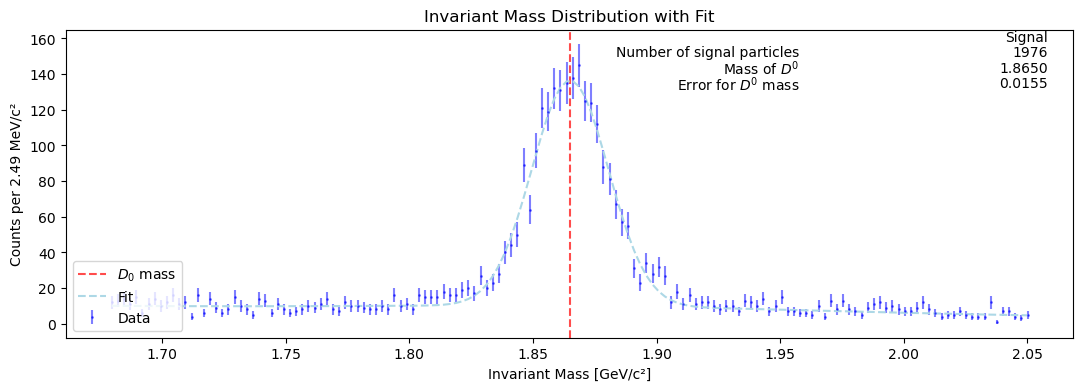

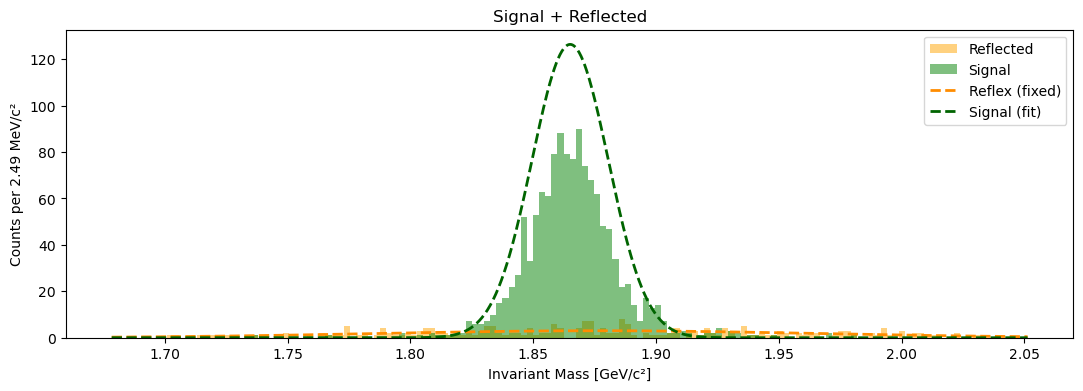

Signal Gaussian: mu = 1.865043, sigma = 0.015508
Reflex Gaussian (fixed): mu = 1.876465, sigma = 0.089194
Fitted amplitude ratio N1/N2 = 0.1370
Results of signal fit: D0 mass  1.865043        error 0.015508
Ratio N1/N2: 0.993913


In [7]:
# --- Fit function: 1 free Gaussian (signal) + 1 FIXED Gaussian (reflex) + linear background ---
ratio = ratio_from_fit   # fixed ratio from previous fit N_signal/N_reflex

def fit_function(x, k, mu1, sigma1, a, b):
    reflex_part  = norm.pdf(x, loc=mu_reflex, scale=sigma_reflex)
    signal_part  = norm.pdf(x, loc=mu1,       scale=sigma1)
    background   = a*x + b
    return k * ( ratio*reflex_part + signal_part) + background


# INITIALIZATIONS:
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 150
binsize = (MAX_MASS - MIN_MASS)/N_BINS

# Initial parameter guesses
k_param       = 100
signal_params = [m_d0, 0.02]
back_params   = [133, 1000]

# --- Data ---
data = np.concatenate([final_results[final_results["new_particle"]=="D0"]["inv_mass"],
                      final_results[final_results["new_particle"]=="Anti-D0"]["anti_mass"],
                      final_results[final_results["new_particle"]=="Undecided"]["inv_mass"],
                      final_results[final_results["new_particle"]=="Undecided"]["anti_mass"]])

# HISTOGRAM:
fig, ax = plt.subplots(figsize=(13,4))
both_counts, both_edges = np.histogram(data, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
both_centers = (both_edges[:-1] + both_edges[1:]) / 2.0
# --- Poisson errors ---
sigma_hist = np.sqrt(both_counts)
sigma_hist = np.clip(sigma_hist, 1, None)
# plot:
ax.errorbar(both_centers, both_counts, yerr=sigma_hist, fmt='.', markersize=2, color='blue', alpha=0.5, label='Data')
ax.axvline(x=m_d0, color="red", ls='--', label=r"$D_0$ mass", alpha=0.7)

# FIT:
both_fit_res = curve_fit(
    f       = fit_function,
    xdata   = both_centers,
    ydata   = both_counts,
    sigma   = sigma_hist,
    p0      = [
        k_param,                # 0: k
        signal_params[0],       # 1: mu1
        signal_params[1],       # 2: sigma1
        back_params[0],         # 3: a
        back_params[1]          # 4: b
    ]
)

both_params = both_fit_res[0]
k_fit, mu1, sigma1, a_fit, b_fit = both_params

# PLOT fitted curve:
ax.plot( both_centers, fit_function(both_centers, *both_params),
    color='lightblue', linestyle='dashed', linewidth=1.5, label='Fit'
)

# COUNT of D0 from the signal Gaussian only:
mass_from_fit  = mu1
sigma_from_fit = sigma1
counts_from_fit =  ( k_fit * (norm.cdf(MAX_MASS, loc=mu1, scale=sigma1) - norm.cdf(MIN_MASS, loc=mu1, scale=sigma1)) ) / binsize

# TABLE INSIDE PLOT:
ax.table(
    cellText = [[f"{counts_from_fit:.0f}"], [f"{mass_from_fit:.4f}"], [f"{sigma_from_fit:.4f}"]],
    rowLabels = [r'Number of signal particles', r'Mass of $D^0$', r'Error for $D^0$ mass'],
    colLabels = ['Signal'],
    colLoc = "right",
    bbox = [0.75, 0.8, 0.25, 0.2],
    edges = 'open',
    rowLoc = 'right'
)

ax.set_xlabel("Invariant Mass [GeV/c²]")
ax.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
ax.set_title("Invariant Mass Distribution with Fit")
ax.legend(loc='lower left')
plt.show()

# ---------------------------------------------------------------------------------------
# SECOND PLOT: signal and reflected plot with fixed Gaussian for reflex

fig, ax = plt.subplots(figsize=(13,4))

ax.hist(reflex_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS),
        color='orange', alpha=0.5, label='Reflected')
ax.hist(signal_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS),
        color='green', alpha=0.5, label='Signal')

# FITTED CURVES:
x_fit = np.linspace(MIN_MASS, MAX_MASS, 1000)
# Fixed reflex Gaussian
ax.plot(x_fit, k_fit * ratio * norm.pdf(x_fit, mu_reflex, sigma_reflex), '--', color='darkorange', linewidth=2, label='Reflex (fixed)')
# Signal Gaussian
ax.plot(x_fit, k_fit * norm.pdf(x_fit, mu1, sigma1), '--', color='darkgreen', linewidth=2, label='Signal (fit)')

ax.set_xlabel("Invariant Mass [GeV/c²]")
ax.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
ax.set_title("Signal + Reflected")
ax.legend()
plt.show()

print(f"Signal Gaussian: mu = {mu1:.6f}, sigma = {sigma1:.6f}")
print(f"Reflex Gaussian (fixed): mu = {mu_reflex:.6f}, sigma = {sigma_reflex:.6f}")
print(f"Fitted amplitude ratio N1/N2 = {ratio:.4f}")

print(f"Results of signal fit: D0 mass  {mass_from_fit:3f}        error {sigma_from_fit:3f}")
print(f"Ratio N1/N2: {mu1/mu_reflex:3f}")

In [8]:
print(f"True number of signal particles:     {np.sum(mask_signal)}")
print(f"Expected number of signal particles: {counts_from_fit:.0f}")

True number of signal particles:     1340
Expected number of signal particles: 1976
